In [1]:
# Внимание!!! Важно, что бы файлы с данными и исполняемый файл находились в одной папке, 
# тогда пути к тестовым и тренировочным наборам будут содержать только имена файлов.
# 
# В пути к тренировочным и тестовым данным запрежается использовать абсалютную адресацию, 
# то есть адресацию, в которой присутствуют имена папок. Путь должен содержать только имя файла.
#
# Напоминание: под моделью машинного обучения понимаются все действия с исходными данными, 
# которые необходимо произвести, что бы сопоставить признаки целевому значению.

### Область работы 1 (библиотеки)

In [2]:
# Данный блок в области 1 НЕ выполняется преподавателем
# 
# данный блок предназначен только для подключения необходимых библиотек
# запрещается подключать библиотеки в других блоках
#
# установка дополнительных библиотек размещается прямо здесь (обязательно закоментированы)
#pip install tqdm.auto
#pip install tqdm.joblib


In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_log_error
from IPython.display import display
from sklearn.datasets import load_iris
from sklearn.neighbors import KNeighborsRegressor 
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.compose import ColumnTransformer, make_column_transformer
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.preprocessing import RobustScaler, Normalizer
from sklearn.preprocessing import MinMaxScaler, PolynomialFeatures, StandardScaler, OneHotEncoder, RobustScaler
from sklearn.model_selection import train_test_split, cross_val_score  
from sklearn.model_selection import GridSearchCV, KFold, StratifiedShuffleSplit
from sklearn.model_selection import GridSearchCV, KFold, ParameterGrid
from tqdm.auto import tqdm
from tqdm_joblib import tqdm_joblib
from sklearn.compose import TransformedTargetRegressor
from sklearn.preprocessing import QuantileTransformer, PowerTransformer
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from sklearn.svm import SVR
from sklearn.linear_model import Ridge, Lasso, ElasticNet, Lars, OrthogonalMatchingPursuit, SGDRegressor
from sklearn.preprocessing import (
    QuantileTransformer, PowerTransformer, FunctionTransformer
)
import numpy as np
from sklearn.metrics import classification_report
from sklearn.preprocessing import PolynomialFeatures
import category_encoders as ce
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler

import sklearn
print(sklearn.__version__)


1.7.2


### Область работы 2 (поиск  модели .... )

In [4]:
# Данный блок(и) НЕ выполняются преподавателем в области 2
# блок(и) предназначены для поиска лучшей модели 
# должен быть понятен и очевиден отбор параметров модели
# 
# Запрещается размещать данные блоки за пределами обасти 2
# Все блоки данной области должны быть выполнены
#
# ЗАПРЕЩАЕТСЯ ИСПОЛЬЗОВАТЬ ТЕСТОВЫЙ НАБОР
#
# Путь к тренировочному набору
# 

path_train = 'train.csv'# содержит только имя файла, без имен папок !!!
path_test  = 'test.csv'

Выгружаем данные и смотрим на них

In [5]:
df = pd.read_csv("train.csv")
display(df.head())

,size,color,fancy_color_dominant_color,fancy_color_secondary_color,fancy_color_overtone,fancy_color_intensity,clarity,cut,symmetry,polish,...,meas_length,meas_width,meas_depth,girdle_min,girdle_max,culet_condition,fluor_color,fluor_intensity,total_sales_price,eye_clean
0,0.76,D,NaN,NaN,NaN,NaN,I1,Excellent,Excellent,Excellent,...,6.02,6.04,3.55,TN,M,NaN,NaN,NaN,3712,NaN
1,1.00,H,NaN,NaN,NaN,NaN,VVS1,Very Good,Excellent,Excellent,...,6.27,6.32,4.03,STK,TK,NaN,NaN,NaN,9717,NaN
2,0.30,F,NaN,NaN,NaN,NaN,VS1,Very Good,Very Good,Very Good,...,4.33,4.36,2.60,XTN,M,NaN,NaN,NaN,954,NaN
3,0.30,D,NaN,NaN,NaN,NaN,SI1,Excellent,Very Good,Excellent,...,4.24,4.29,2.67,STK,STK,NaN,NaN,Faint,858,NaN
4,0.32,F,NaN,NaN,NaN,NaN,VS1,Excellent,Excellent,Excellent,...,4.39,4.40,2.73,M,STK,NaN,NaN,NaN,1150,Yes


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61445 entries, 0 to 61444
Data columns (total 22 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   size                         61445 non-null  float64
 1   color                        61445 non-null  object 
 2   fancy_color_dominant_color   0 non-null      float64
 3   fancy_color_secondary_color  0 non-null      float64
 4   fancy_color_overtone         0 non-null      float64
 5   fancy_color_intensity        0 non-null      float64
 6   clarity                      61445 non-null  object 
 7   cut                          61445 non-null  object 
 8   symmetry                     61445 non-null  object 
 9   polish                       61445 non-null  object 
 10  depth_percent                61445 non-null  float64
 11  table_percent                61445 non-null  float64
 12  meas_length                  61445 non-null  float64
 13  meas_width      

In [7]:
df.describe()


,size,fancy_color_dominant_color,fancy_color_secondary_color,fancy_color_overtone,fancy_color_intensity,depth_percent,table_percent,meas_length,meas_width,meas_depth,total_sales_price
count,61445.000000,0.0,0.0,0.0,0.0,61445.000000,61445.000000,61445.000000,61445.0000,61445.000000,61445.000000
mean,0.480407,NaN,NaN,NaN,NaN,62.101587,57.799370,4.857504,4.8888,3.026854,2524.963561
std,0.262129,NaN,NaN,NaN,NaN,1.302779,1.809108,0.793800,0.7988,0.497674,2959.193410
min,0.150000,NaN,NaN,NaN,NaN,56.000000,50.000000,3.390000,3.4200,2.100000,264.000000
25%,0.300000,NaN,NaN,NaN,NaN,61.400000,56.000000,4.290000,4.3100,2.680000,892.000000
50%,0.370000,NaN,NaN,NaN,NaN,62.300000,58.000000,4.580000,4.6100,2.850000,1208.000000
75%,0.550000,NaN,NaN,NaN,NaN,62.800000,59.000000,5.230000,5.2600,3.250000,3024.000000
max,1.490000,NaN,NaN,NaN,NaN,66.500000,67.000000,7.430000,7.5300,4.500000,31133.000000


In [8]:
df.duplicated().unique()

array([False])

Замечаем, что в датасете нет дублей

(0.0, 3.0)

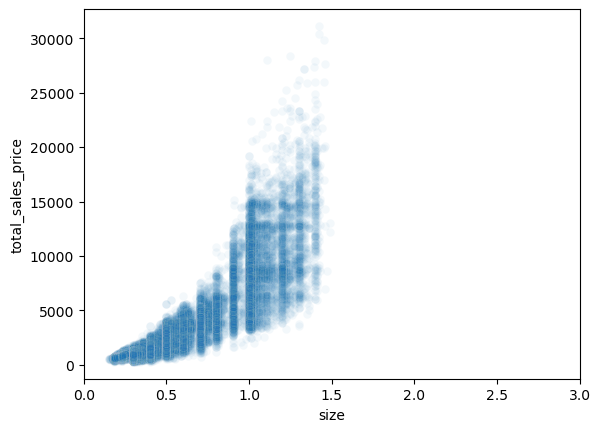

In [9]:
sns.scatterplot(data = df, x = 'size', y = 'total_sales_price', alpha=0.05);
plt.xlim(0,3)

In [10]:
df[df.eq(0).any(axis=1)]

,size,color,fancy_color_dominant_color,fancy_color_secondary_color,fancy_color_overtone,fancy_color_intensity,clarity,cut,symmetry,polish,...,meas_length,meas_width,meas_depth,girdle_min,girdle_max,culet_condition,fluor_color,fluor_intensity,total_sales_price,eye_clean


In [11]:
display(df.culet_condition.info())
display(df.culet_condition.unique())
display(df.culet_condition.value_counts())

<class 'pandas.core.series.Series'>
RangeIndex: 61445 entries, 0 to 61444
Series name: culet_condition
Non-Null Count  Dtype 
--------------  ----- 
2605 non-null   object
dtypes: object(1)
memory usage: 480.2+ KB


None

array([nan, 'Pointed', 'Chipped'], dtype=object)

culet_condition
Pointed    2604
Chipped       1
Name: count, dtype: int64

<Axes: >

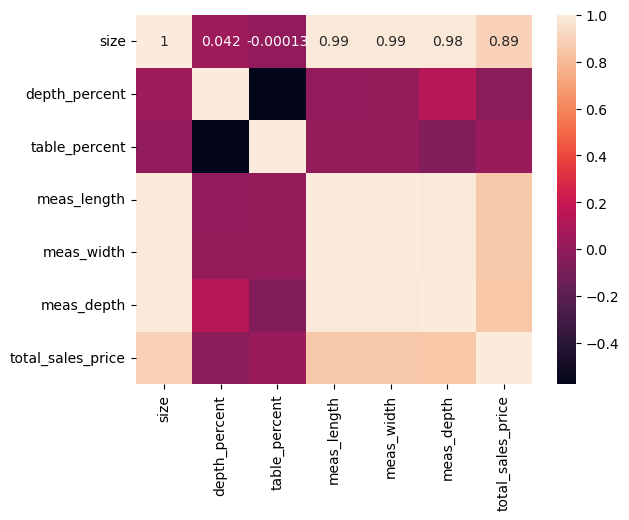

In [12]:
sns.heatmap(df[['size', 'depth_percent', 'table_percent', 'meas_length', 'meas_width', 'meas_depth', 'total_sales_price']].corr(), annot=True)

Дропаем пустые колонки, а так же culet_condition, так как как известно, что отсутствует нижняя площадка

In [13]:
df = df.drop(columns = ['fancy_color_dominant_color', 'fancy_color_secondary_color', 'fancy_color_overtone', 'fancy_color_intensity', 'culet_condition'])

In [14]:
y = np.array(df.total_sales_price)
X = df.drop(columns=['total_sales_price'])

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

Сплитим датасет и еще раз смотрим на признаки, чтобы понять, как их обрабатывать

In [15]:
df

,size,color,clarity,cut,symmetry,polish,depth_percent,table_percent,meas_length,meas_width,meas_depth,girdle_min,girdle_max,fluor_color,fluor_intensity,total_sales_price,eye_clean
0,0.76,D,I1,Excellent,Excellent,Excellent,58.9,60.0,6.02,6.04,3.55,TN,M,NaN,NaN,3712,NaN
1,1.00,H,VVS1,Very Good,Excellent,Excellent,63.9,58.0,6.27,6.32,4.03,STK,TK,NaN,NaN,9717,NaN
2,0.30,F,VS1,Very Good,Very Good,Very Good,59.9,59.0,4.33,4.36,2.60,XTN,M,NaN,NaN,954,NaN
3,0.30,D,SI1,Excellent,Very Good,Excellent,62.7,58.0,4.24,4.29,2.67,STK,STK,NaN,Faint,858,NaN
4,0.32,F,VS1,Excellent,Excellent,Excellent,62.0,59.0,4.39,4.40,2.73,M,STK,NaN,NaN,1150,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61440,0.40,D,SI2,Excellent,Excellent,Excellent,62.9,56.0,4.67,4.71,2.95,NaN,NaN,NaN,Faint,1188,NaN
61441,0.30,D,VVS2,Excellent,Excellent,Excellent,61.7,61.0,4.27,4.30,2.64,M,STK,Blue,Medium,992,Yes
61442,0.32,G,VS2,Excellent,Excellent,Excellent,60.4,57.0,4.42,4.44,2.68,M,TK,Blue,Medium,1008,NaN
61443,0.60,H,VS2,Excellent,Excellent,Excellent,63.2,55.0,5.35,5.37,3.39,NaN,NaN,NaN,NaN,3730,NaN


In [16]:
display(df['color'].unique())
df['color'].nunique()

array(['D', 'H', 'F', 'L', 'G', 'K', 'M', 'I', 'J', 'E'], dtype=object)

10

In [17]:
display(df['clarity'].unique())
df['clarity'].nunique()

array(['I1', 'VVS1', 'VS1', 'SI1', 'VS2', 'VVS2', 'SI2', 'IF', 'I2', 'I3'],
      dtype=object)

10

In [18]:
display(df['cut'].unique())
df['cut'].nunique()

array(['Excellent', 'Very Good'], dtype=object)

2

In [19]:
display(df['symmetry'].unique())
df['symmetry'].nunique()

array(['Excellent', 'Very Good'], dtype=object)

2

In [20]:
display(df['polish'].unique())
df['polish'].nunique()

array(['Excellent', 'Very Good'], dtype=object)

2

In [21]:
display(df['girdle_min'].unique())
df['girdle_min'].nunique()

array(['TN', 'STK', 'XTN', 'M', nan, 'TK', 'VTN', 'STN', 'VTK'],
      dtype=object)

8

In [22]:
display(df['girdle_max'].unique())
df['girdle_min'].nunique()

array(['M', 'TK', 'STK', nan, 'VTK', 'TN', 'XTK', 'XTN', 'STN', 'VTN'],
      dtype=object)

8

In [23]:
display(df['fluor_color'].unique())
df['fluor_color'].nunique()

array([nan, 'Yellow', 'Blue', 'Green', 'White', 'Orange'], dtype=object)

5

In [24]:
display(df['fluor_intensity'].unique())
df['fluor_intensity'].nunique()

array([nan, 'Faint', 'Medium', 'Strong', 'Very Strong', 'Very Slight'],
      dtype=object)

5

In [25]:
display(df['eye_clean'].unique())
df['eye_clean'].nunique()

array([nan, 'Yes', 'E1', 'Borderline', 'No'], dtype=object)

4

Посмотрев на то, какие значения встречаются у признаков, группируем их

In [71]:
num_features = ['size','depth_percent','table_percent']
meas_features = ['meas_length', 'meas_width', 'meas_depth']
girdle_features = ['girdle_min', 'girdle_max']
b_ordered_features = ['cut', 'symmetry', 'polish']
ordered_features = ['color', 'clarity', 'fluor_intensity', 'eye_clean'] 
one_hot_features = ['fluor_color']

Пишем колумн трансформер для предобработки

In [27]:
fluor_color_transformer = Pipeline(steps=[
    ('missing_сat', SimpleImputer(strategy = 'most_frequent')),
    ("cat_encoding", OneHotEncoder(sparse_output=False))])

_girdle_map = {
    'XTN': 0,   
    'VTN': 1,   
    'STN': 2,   
    'TN' : 3,  
    'M'  : 4,  
    'STK': 5,   
    'TK' : 6,   
    'VTK': 7,   
    'XTK': 8   
}

girdle_both_map = [
    {'col': 'girdle_min', 'mapping': _girdle_map},
    {'col': 'girdle_max', 'mapping': _girdle_map},
]
girdle_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ord', ce.OrdinalEncoder(mapping=girdle_both_map))
])

num_transformer = Pipeline(steps=[
    ('missing_num', SimpleImputer(strategy = 'mean')),
    ('scaler', StandardScaler())])

meas_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('polynom', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler())
])

binary_transformer = Pipeline(steps=[
    ('missing_num', SimpleImputer(strategy='most_frequent')),
    ('ce', ce.OrdinalEncoder(cols=b_ordered_features))   
])

color_map = [{
    'col': 'color',
    'mapping': {
        'D': 10, 'E': 9, 'F': 8, 'G': 7, 'H': 6,
        'I': 5, 'J': 4, 'K': 3, 'L': 2, 'M': 1
    }
}]
color_transformer = Pipeline(steps=[
    ('missing_num', SimpleImputer(strategy='most_frequent')),
    ('ce', ce.OrdinalEncoder(mapping=color_map))
])


clarity_map = [{
    'col': 'clarity',
    'mapping': {
        'FL': 10, 'IF': 9, 'VVS1': 8, 'VVS2': 7, 'VS1': 6, 'VS2': 5,
        'SI1': 4, 'SI2': 3, 'I1': 2, 'I2': 1, 'I3': 0
    }
}]
clarity_transformer = Pipeline(steps=[
    ('missing_num', SimpleImputer(strategy='most_frequent')),
    ('ce', ce.OrdinalEncoder(mapping=clarity_map))
])

fluor_map = [{
    'col': 'fluor_intensity',
    'mapping': {
        'Very Slight': 4,  
        'Faint': 3,
        'Medium': 2,
        'Strong': 1,
        'Very Strong': 0   
    }
}]
fluor_intensity_transformer = Pipeline(steps=[
    ('missing_num', SimpleImputer(strategy='most_frequent')),
    ('ce', ce.OrdinalEncoder(mapping=fluor_map))
])

eyeclean_map = [{
    'col': 'eye_clean',
    'mapping': {
        'Yes': 3,
        'Borderline': 2,
        'No': 1,
        'E1': 0
    }
}]
eyeclean_transformer = Pipeline(steps=[
    ('missing_num', SimpleImputer(strategy='most_frequent')),
    ('ce', ce.OrdinalEncoder(mapping=eyeclean_map))
])


CT = ColumnTransformer([
        ("num_transformer", num_transformer, num_features),
        ("meas_transformer", meas_transformer, meas_features),
        ("girdle_transformer", girdle_transformer, girdle_features),
        ("binary_transformer", binary_transformer, b_ordered_features),
        ("color_map", color_transformer, ['color']),
        ("clarity_map", clarity_transformer, ['clarity']),
        ("fluor_intensity_map", fluor_intensity_transformer, ['fluor_intensity']),
        ("eyeclean_map", eyeclean_transformer, ['eye_clean'])
        ]).set_output(transform='pandas')

display(CT)

ct = CT.fit_transform(X_train)
pd.DataFrame(ct).head().T

,transformers,"[('num_transformer', ...), ('meas_transformer', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'mean'
,fill_value,None


,25119,7560,1846,27954,27666
num_transformer__size,0.071683,-0.690164,-0.385425,0.109775,1.214454
num_transformer__depth_percent,1.615274,-0.230753,0.153836,-0.461507,0.769178
num_transformer__table_percent,-0.441301,0.113165,-0.995767,-0.995767,-1.550233
meas_transformer__meas_length,0.113131,-0.717593,-0.277058,0.327105,1.296283
meas_transformer__meas_width,0.110767,-0.714693,-0.264442,0.323385,1.286422
meas_transformer__meas_depth,0.304203,-0.739567,-0.257827,0.264058,1.408190
meas_transformer__meas_length^2,0.029905,-0.698025,-0.324952,0.234244,1.246176
meas_transformer__meas_length meas_width,0.028823,-0.696990,-0.319456,0.232514,1.240979
meas_transformer__meas_length meas_depth,0.121003,-0.710004,-0.317571,0.205110,1.316516
meas_transformer__meas_width^2,0.027699,-0.695870,-0.313927,0.230706,1.235532


In [28]:
model = Pipeline(steps=[
    ('preproc', CT),
    ('regressor', KNeighborsRegressor())
    ])

model.fit(X_train, y_train)

,steps,"[('preproc', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num_transformer', ...), ('meas_transformer', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [29]:
y_pred = model.predict(X_test)
mean_squared_log_error(y_test, y_pred)

0.012251890991499073

Смотрим разные модели и по решетке подбираем лучшую

In [30]:
pipe =  TransformedTargetRegressor(
                regressor = Pipeline(steps=[
                                ('preproc', CT),
                                ('estimator', Ridge())
                            ]),
                transformer=QuantileTransformer(n_quantiles=1000, output_distribution="uniform")
)

regressors = [Ridge(), ElasticNet(), Lars(), Lasso(), KNeighborsRegressor(), SVR()]
param_grid = [
    {
        'regressor__estimator': regressors
    },
]

grid = GridSearchCV(pipe, param_grid, cv = KFold(5), return_train_score = True, scoring = 'neg_mean_squared_log_error', n_jobs=-1)
grid.fit(X_train, y_train)

,estimator,TransformedTa...Transformer())
,param_grid,"[{'regressor__estimator': [Ridge(), ElasticNet(), ...]}]"
,scoring,'neg_mean_squared_log_error'
,n_jobs,-1
,refit,True
,cv,KFold(n_split...shuffle=False)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,transformers,"[('num_transformer', ...), ('meas_transformer', ...), ...]"


In [31]:
grid_result = pd.DataFrame(grid.cv_results_).sort_values(["rank_test_score",'std_test_score']).T
grid_result

,4,5,2,0,3,1
mean_fit_time,0.682223,14.295792,0.628346,0.593577,0.648253,0.615724
std_fit_time,0.021165,0.635527,0.023437,0.009845,0.025087,0.025715
mean_score_time,3.407999,3.439546,0.116597,0.109643,0.149412,0.125452
std_score_time,0.061855,0.140995,0.005811,0.007622,0.019009,0.025547
param_regressor__estimator,KNeighborsRegressor(),SVR(),Lars(),Ridge(),Lasso(),ElasticNet()
params,{'regressor__estimator': KNeighborsRegressor()},{'regressor__estimator': SVR()},{'regressor__estimator': Lars()},{'regressor__estimator': Ridge()},{'regressor__estimator': Lasso()},{'regressor__estimator': ElasticNet()}
split0_test_score,-0.013351,-0.050009,-0.08698,-0.099554,-0.783112,-0.790924
split1_test_score,-0.013024,-0.050686,-0.09645,-0.093708,-0.797372,-0.797846
split2_test_score,-0.01408,-0.052333,-0.102982,-0.096274,-0.80045,-0.798467
split3_test_score,-0.013505,-0.048604,-0.08177,-0.091499,-0.799035,-0.80268


Видно, что с большим отрывом побеждает KNeighbors, ее и будем использовать, теперь подберем параметры для нее и для колумн трансформера

In [32]:
pipe =  TransformedTargetRegressor(
                regressor = Pipeline(steps=[
                                ('preproc', CT),
                                ('estimator', (KNeighborsRegressor()))
                            ]),
                transformer=QuantileTransformer(n_quantiles=1000, output_distribution="uniform")
)

n_neighbors = [8, 10, 12, 13, 14, 15, 15]
scalers = [StandardScaler(), MinMaxScaler(), RobustScaler()]

param_grid = [{
    'regressor__estimator': [KNeighborsRegressor()],
    'regressor__estimator__n_neighbors': n_neighbors,
    'regressor__estimator__p': [1],             
    'regressor__estimator__weights': ['distance'],
    'regressor__estimator__n_jobs': [-1],
    'regressor__preproc__num_transformer__scaler': scalers,
    'regressor__preproc__meas_transformer__scaler': scalers,
}]

cv = KFold(n_splits=5, shuffle=True, random_state=42)
grid = GridSearchCV(
    estimator=pipe,                     
    param_grid=param_grid,
    cv=cv,
    return_train_score=True,
    scoring='neg_mean_squared_log_error',  
    n_jobs=-1
)
total = len(list(ParameterGrid(param_grid))) * cv.get_n_splits()

with tqdm_joblib(tqdm(total=total, desc="GridSearchCV", ncols=100)):
    grid.fit(X_train, y_train)

GridSearchCV:   0%|                                                         | 0/315 [00:00<?, ?it/s]

  0%|          | 0/315 [00:00<?, ?it/s]

In [33]:
grid_result = pd.DataFrame(grid.cv_results_).sort_values(["rank_test_score",'std_test_score']).T
grid_result

,19,25,34,16,10,28,43,61,52,37,...,40,12,3,49,21,58,30,39,57,48
mean_fit_time,0.55647,0.542087,0.564633,0.438462,0.419481,0.600385,0.594518,0.564006,0.6443,0.825492,...,0.530534,0.41339,0.424183,0.535955,0.631564,0.575757,0.572835,0.54306,0.54369,0.532567
std_fit_time,0.099224,0.014078,0.010435,0.013653,0.019033,0.067234,0.07844,0.03027,0.098567,0.141071,...,0.007442,0.00972,0.018328,0.013817,0.065769,0.055797,0.070006,0.006281,0.015041,0.014257
mean_score_time,15.493376,14.218852,14.587133,10.97164,10.609168,14.84417,14.435041,16.141423,15.487272,18.500571,...,13.701134,10.384391,10.311619,14.08927,15.396709,14.860873,14.000043,13.924754,14.211579,13.830829
std_score_time,0.851886,0.416848,0.488595,0.398147,0.102537,0.675849,0.237556,0.788758,0.860226,2.398087,...,0.055677,0.102119,0.133715,0.17747,0.383854,0.373221,0.259444,0.183267,0.210379,0.218418
param_regressor__estimator,KNeighborsRegressor(),KNeighborsRegressor(),KNeighborsRegressor(),KNeighborsRegressor(),KNeighborsRegressor(),KNeighborsRegressor(),KNeighborsRegressor(),KNeighborsRegressor(),KNeighborsRegressor(),KNeighborsRegressor(),...,KNeighborsRegressor(),KNeighborsRegressor(),KNeighborsRegressor(),KNeighborsRegressor(),KNeighborsRegressor(),KNeighborsRegressor(),KNeighborsRegressor(),KNeighborsRegressor(),KNeighborsRegressor(),KNeighborsRegressor()
param_regressor__estimator__n_jobs,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,...,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1
param_regressor__estimator__n_neighbors,12,12,13,10,10,13,14,15,15,14,...,14,10,8,15,12,15,13,14,15,15
param_regressor__estimator__p,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
param_regressor__estimator__weights,distance,distance,distance,distance,distance,distance,distance,distance,distance,distance,...,distance,distance,distance,distance,distance,distance,distance,distance,distance,distance
param_regressor__preproc__meas_transformer__scaler,StandardScaler(),RobustScaler(),RobustScaler(),RobustScaler(),StandardScaler(),StandardScaler(),RobustScaler(),RobustScaler(),RobustScaler(),StandardScaler(),...,MinMaxScaler(),MinMaxScaler(),MinMaxScaler(),MinMaxScaler(),MinMaxScaler(),MinMaxScaler(),MinMaxScaler(),MinMaxScaler(),MinMaxScaler(),MinMaxScaler()


In [37]:
grid.best_params_

{'regressor__estimator': KNeighborsRegressor(),
 'regressor__estimator__n_jobs': -1,
 'regressor__estimator__n_neighbors': 12,
 'regressor__estimator__p': 1,
 'regressor__estimator__weights': 'distance',
 'regressor__preproc__meas_transformer__scaler': StandardScaler(),
 'regressor__preproc__num_transformer__scaler': MinMaxScaler()}

Получаем лучшие параметры для нашей итоговой модели

In [59]:
CT_final = CT.set_params(
    meas_transformer__scaler=StandardScaler(),
    num_transformer__scaler=MinMaxScaler()
)

Перебираем решеткой для нашей лучшей модели различные трансформеры для таргета

In [64]:
tt_log = FunctionTransformer(np.log1p, inverse_func=np.expm1, validate=False)
tt_qnorm = QuantileTransformer(n_quantiles=1000, output_distribution="normal")
tt_quni  = QuantileTransformer(n_quantiles=1000, output_distribution="uniform")
tt_power   = PowerTransformer()
tt_none  = 'passthrough'

final_pipe = TransformedTargetRegressor(
    regressor = Pipeline(steps=[
        ('preproc', CT_final),
        ('estimator', KNeighborsRegressor(
            n_neighbors=12,
            p=1,
            weights='distance',
            n_jobs=-1
        ))
    ]),
    transformer = tt_power 
)

param_grid = [{
    'transformer': [tt_log, tt_qnorm, tt_quni, tt_power, tt_none],
}]

cv = KFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    estimator=final_pipe,
    param_grid=param_grid,
    cv=cv,
    scoring='neg_mean_squared_log_error',   
    return_train_score=True,
    n_jobs=-1
)
grid.fit(X_train, y_train)


C:\Users\gserb\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
5 fits failed out of a total of 25.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\gserb\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\gserb\anaconda3\Lib\site-packages\sklearn\base.py", line 1358, in wrapper
    estimator._validate_params()
  File "C:\Users\gserb\anaconda3\Lib\site-packages\sklearn\base.py", line 471, in _validate_params
    validate_parameter_constraints(
  File "C:\Users\gserb\anaconda3\Lib\site-packages\sk

,estimator,TransformedTa...Transformer())
,param_grid,"[{'transformer': [FunctionTrans...func 'expm1'>), QuantileTrans...tion='normal'), ...]}]"
,scoring,'neg_mean_squared_log_error'
,n_jobs,-1
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,transformers,"[('num_transformer', ...), ('meas_transformer', ...), ...]"


In [66]:
grid_result = pd.DataFrame(grid.cv_results_).sort_values(["rank_test_score",'std_test_score']).T
grid_result

,3,1,0,2,4
mean_fit_time,0.513462,0.582025,0.606248,0.48126,0.010416
std_fit_time,0.012684,0.041892,0.025323,0.031346,0.000203
mean_score_time,8.62015,10.510071,10.361604,9.515231,0.0
std_score_time,0.158747,0.165089,0.021596,0.945168,0.0
param_transformer,PowerTransformer(),QuantileTransformer(output_distribution='normal'),"FunctionTransformer(func=<ufunc 'log1p'>, inve...",QuantileTransformer(),passthrough
params,{'transformer': PowerTransformer()},{'transformer': QuantileTransformer(output_dis...,{'transformer': FunctionTransformer(func=<ufun...,{'transformer': QuantileTransformer()},{'transformer': 'passthrough'}
split0_test_score,-0.00901,-0.009147,-0.00916,-0.0094,NaN
split1_test_score,-0.008975,-0.009128,-0.009168,-0.009361,NaN
split2_test_score,-0.008989,-0.00915,-0.009166,-0.00946,NaN
split3_test_score,-0.009548,-0.009643,-0.009746,-0.009996,NaN


In [65]:
grid.best_params_

{'transformer': PowerTransformer()}

Лучший трансформер - PowerTransformer, в финальной спецификации используем его

In [69]:
best_pipe = TransformedTargetRegressor(
    regressor = Pipeline(steps=[
        ('preproc', CT_final),
        ('estimator', KNeighborsRegressor(
            n_neighbors=12,
            p=1,
            weights='distance',
            n_jobs=-1
        ))
    ]),
    transformer = PowerTransformer() 
)
best_model = best_pipe.fit(X_train, y_train)

Смотрим значение целовой метрики на тестовой части датасета для нашей финальной модели

In [70]:
y_pred = best_model.predict(X_test)
mean_squared_log_error(y_test, y_pred)

0.008456898134386725